# Notebook 05 - Comparaison Finale & Analyse SHAP
**Projet :** Cadre méthodologique pour la prévision du crédit bancaire dans l'UEMOA basé sur une comparaison entre modèles économétriques et de machine learning : application au Bénin
**Phase :** Tableau comparatif final + SHAP approfondi + Interprétation économique

Ce notebook consolide les résultats de l'ensemble des modèles étudiés.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DATA_PATH = Path('../data/panel_uemoa_complet.csv')
FIG_PATH  = Path('../figures')
FIG_PATH.mkdir(exist_ok=True)

print('Environnement OK')

Environnement OK


In [16]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    return {
        'RMSE':     float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':      float(mean_absolute_error(yt, yp)),
        'R2':       float(r2_score(yt, yp)),
        'MAPE (%)': float(np.mean(np.abs((yt - yp) / yt)) * 100)
    }

---
## 1. Données et ré-entraînement des modèles ML (random_state=42)

In [17]:
VARS_FE = [
    'pib_croissance', 'inflation_ipc', 'masse_monetaire_m2_pib',
    'imf_dette_publique', 'ouverture_commerciale', 'ide_pib',
    'wgi_controle_corruption', 'bceao_taux_directeur',
]
TARGET = 'credit_prive_pib'

df = pd.read_csv(DATA_PATH).sort_values(['iso3', 'annee']).reset_index(drop=True)
df_ml = df[['iso3', 'annee', TARGET] + VARS_FE].copy()
df_ml[VARS_FE] = df_ml.groupby('iso3')[VARS_FE].transform(
    lambda x: x.interpolate(method='linear', limit=2)
)
df_ml = df_ml.sort_values(['iso3', 'annee'])
df_ml['credit_L1'] = df_ml.groupby('iso3')[TARGET].shift(1)
le = LabelEncoder()
df_ml['iso3_enc'] = le.fit_transform(df_ml['iso3'])
df_ml = df_ml.dropna().reset_index(drop=True)

FEAT_COLS = ['credit_L1', 'annee', 'iso3_enc'] + VARS_FE
# Noms lisibles pour les graphiques SHAP
FEAT_LABELS = [
    'Credit (t-1)', 'Annee', 'Pays (enc.)',
    'Croiss. PIB', 'Inflation', 'M2/PIB',
    'Dette pub./PIB', 'Ouverture com.', 'IDE/PIB',
    'WGI Corruption', 'Taux BCEAO'
]

train_ml = df_ml[df_ml['annee'] <= 2019].copy().reset_index(drop=True)
test_ml  = df_ml[df_ml['annee'] >= 2020].copy().reset_index(drop=True)
X_train = train_ml[FEAT_COLS].values.astype(float)
y_train = train_ml[TARGET].values.astype(float)
X_test  = test_ml[FEAT_COLS].values.astype(float)
y_test  = test_ml[TARGET].values.astype(float)

# Re-entrainement RF
rf = RandomForestRegressor(
    n_estimators=300, max_depth=6, min_samples_leaf=3,
    max_features=0.7, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

# Re-entrainement XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print('Modeles RF et XGBoost re-entraines (random_state=42)')
print(f'Train : {X_train.shape} | Test : {X_test.shape}')

Modeles RF et XGBoost re-entraines (random_state=42)
Train : (147, 11) | Test : (40, 11)


---
## 2. Tableau Comparatif Final

Métriques sur le**même périmètre test** (2020-2024) pour tous les modèles.
Les métriques ARDL et Panel FE proviennent du Notebook 03.

In [18]:
# Predictions ML
m_rf_tr  = compute_metrics(y_train, rf.predict(X_train))
m_rf_te  = compute_metrics(y_test,  rf.predict(X_test))
m_xgb_tr = compute_metrics(y_train, xgb_model.predict(X_train))
m_xgb_te = compute_metrics(y_test,  xgb_model.predict(X_test))

# Metriques econometrie (Notebook 03)
m_ardl_is  = {'RMSE': 0.7444, 'MAE': 0.6434, 'R2': 0.9504,  'MAPE (%)': 4.83}
m_ardl_oos = {'RMSE': 3.0712, 'MAE': 3.0008, 'R2': -3.4435, 'MAPE (%)': 17.65}
m_fe_tr    = {'RMSE': 1.8953, 'MAE': 1.4480, 'R2': 0.9241,  'MAPE (%)': 15.77}
m_fe_te    = {'RMSE': 2.4170, 'MAE': 1.9093, 'R2': 0.8772,  'MAPE (%)': 8.96}

rows = [
    {'Modele': 'ARDL - Benin',       'Type': 'Econometrie', 'Period': 'IS  T=24',
     **{k: round(v,4) for k,v in m_ardl_is.items()}},
    {'Modele': 'ARDL - Benin',       'Type': 'Econometrie', 'Period': 'OOS T=5',
     **{k: round(v,4) for k,v in m_ardl_oos.items()}},
    {'Modele': 'Panel FE UEMOA',     'Type': 'Econometrie', 'Period': 'TR  N=8',
     **{k: round(v,4) for k,v in m_fe_tr.items()}},
    {'Modele': 'Panel FE UEMOA',     'Type': 'Econometrie', 'Period': 'TE  N=8',
     **{k: round(v,4) for k,v in m_fe_te.items()}},
    {'Modele': 'Random Forest',      'Type': 'ML',          'Period': 'TR  N=8',
     **{k: round(v,4) for k,v in m_rf_tr.items()}},
    {'Modele': 'Random Forest',      'Type': 'ML',          'Period': 'TE  N=8',
     **{k: round(v,4) for k,v in m_rf_te.items()}},
    {'Modele': 'XGBoost',            'Type': 'ML',          'Period': 'TR  N=8',
     **{k: round(v,4) for k,v in m_xgb_tr.items()}},
    {'Modele': 'XGBoost',            'Type': 'ML',          'Period': 'TE  N=8',
     **{k: round(v,4) for k,v in m_xgb_te.items()}},
]
df_comp = pd.DataFrame(rows)

print('=' * 82)
print('TABLEAU COMPARATIF FINAL - ECONOMETRIE vs MACHINE LEARNING')
print('=' * 82)
print(df_comp.to_string(index=False))
print('=' * 82)

# Meilleur modele test (RMSE)
test_df = df_comp[df_comp['Period'].str.startswith('TE')].copy()
best_rmse = test_df.loc[test_df['RMSE'].idxmin()]
best_r2   = test_df.loc[test_df['R2'].idxmax()]
best_rmse_v = round(float(best_rmse['RMSE']), 4)
best_r2_v   = round(float(best_r2['R2']), 4)
print(f'Meilleur RMSE test : {best_rmse["Modele"]} - RMSE={best_rmse_v}')
print(f'Meilleur R2   test : {best_r2["Modele"]}   - R2={best_r2_v}')

TABLEAU COMPARATIF FINAL — ECONOMETRIE vs MACHINE LEARNING
        Modele        Type   Period   RMSE    MAE      R2  MAPE (%)
  ARDL — Benin Econometrie IS  T=24 0.7444 0.6434  0.9504    4.8300
  ARDL — Benin Econometrie  OOS T=5 3.0712 3.0008 -3.4435   17.6500
Panel FE UEMOA Econometrie  TR  N=8 1.8953 1.4480  0.9241   15.7700
Panel FE UEMOA Econometrie  TE  N=8 2.4170 1.9093  0.8772    8.9600
 Random Forest          ML  TR  N=8 0.7254 0.5523  0.9889    6.9943
 Random Forest          ML  TE  N=8 1.8251 1.5361  0.9300    7.5704
       XGBoost          ML  TR  N=8 0.2428 0.1876  0.9988    2.1160
       XGBoost          ML  TE  N=8 2.0127 1.7034  0.9149    8.1760
Meilleur RMSE test : Random Forest — RMSE=1.8251
Meilleur R2   test : Random Forest   — R2=0.93


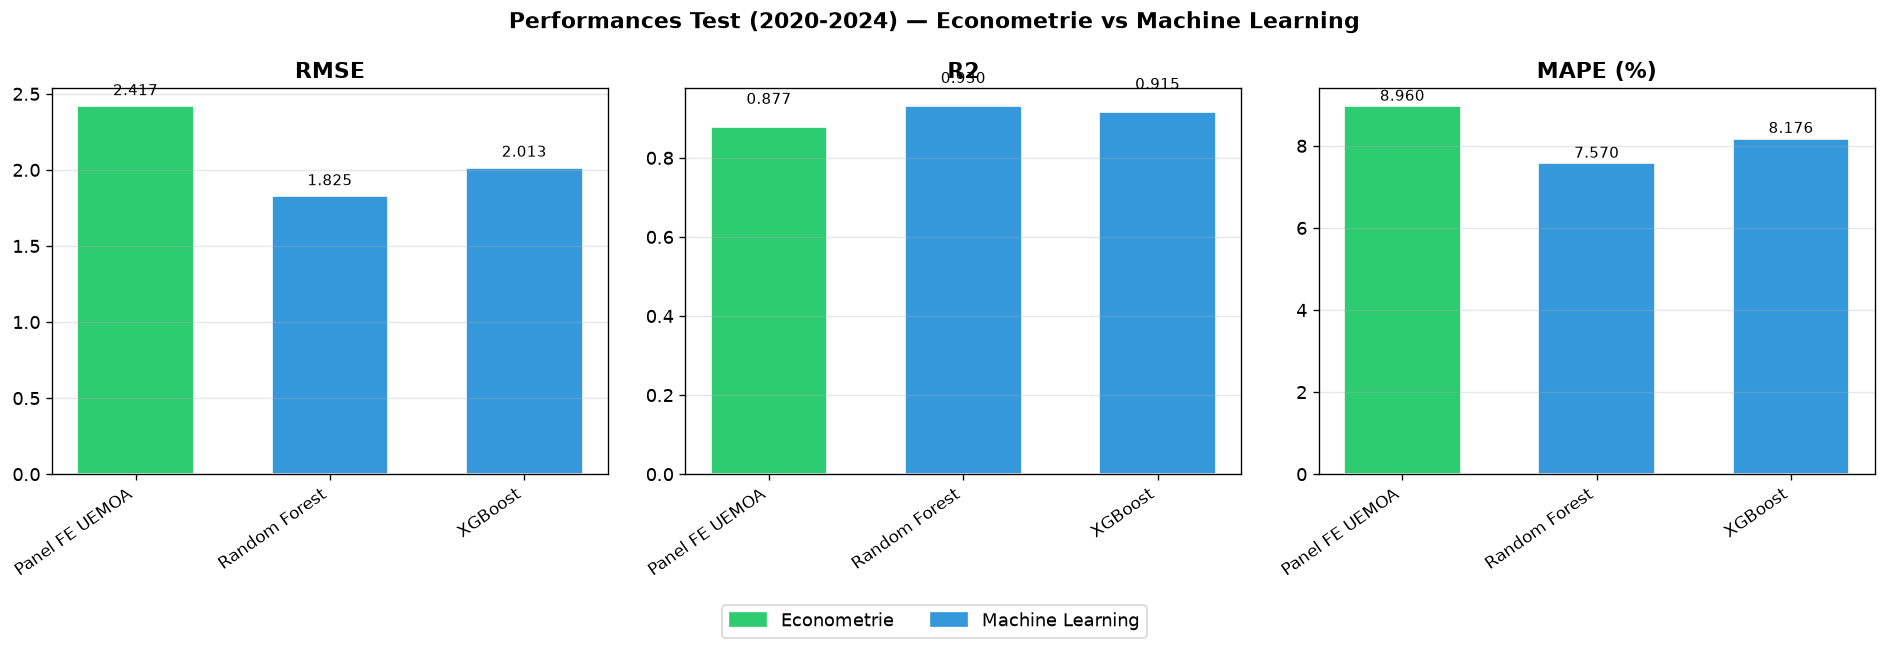

In [19]:
# Graphique comparaison sur perimetre test commun
test_df_plot = df_comp[df_comp['Period'].str.startswith('TE')].reset_index(drop=True)
modeles      = test_df_plot['Modele'].tolist()
type_colors  = {'Econometrie': '#2ecc71', 'ML': '#3498db'}
bar_colors   = [type_colors[t] for t in test_df_plot['Type']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['RMSE', 'R2', 'MAPE (%)']):
    vals = test_df_plot[metric].values.astype(float)
    bars = ax.bar(range(len(modeles)), vals, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(modeles)))
    ax.set_xticklabels(modeles, rotation=35, ha='right', fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    for bar, val in zip(bars, vals):
        ypos = max(bar.get_height(), 0) + 0.05
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', lw=0.5)

patches = [
    mpatches.Patch(color='#2ecc71', label='Econometrie'),
    mpatches.Patch(color='#3498db', label='Machine Learning')
]
fig.legend(handles=patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.08), fontsize=11)
fig.suptitle('Performances Test (2020-2024) - Econometrie vs Machine Learning',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'comparaison_finale_test.png', bbox_inches='tight')
plt.show()

---
## 3. Analyse SHAP approfondie

Les valeurs SHAP (Shapley Additive exPlanations) permettent d'attribuer
la contribution de chaque variable à chaque prédiction individuelle.
Cela répond à la question : *pourquoi le modèle prédit-il X pour ce pays-année ?*

In [20]:
X_train_df = pd.DataFrame(X_train, columns=FEAT_LABELS)
X_test_df  = pd.DataFrame(X_test,  columns=FEAT_LABELS)

# SHAP RF
explainer_rf  = shap.TreeExplainer(rf)
shap_obj_rf   = explainer_rf(X_train_df)
shap_vals_rf  = shap_obj_rf.values
mean_abs_rf   = np.abs(shap_vals_rf).mean(axis=0)

# SHAP XGB
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_obj_xgb  = explainer_xgb(X_train_df)
shap_vals_xgb = shap_obj_xgb.values
mean_abs_xgb  = np.abs(shap_vals_xgb).mean(axis=0)

print('SHAP calcule : RF et XGBoost')
print(f'  Train obs : {len(X_train_df)}')

SHAP calcule : RF et XGBoost
  Train obs : 147


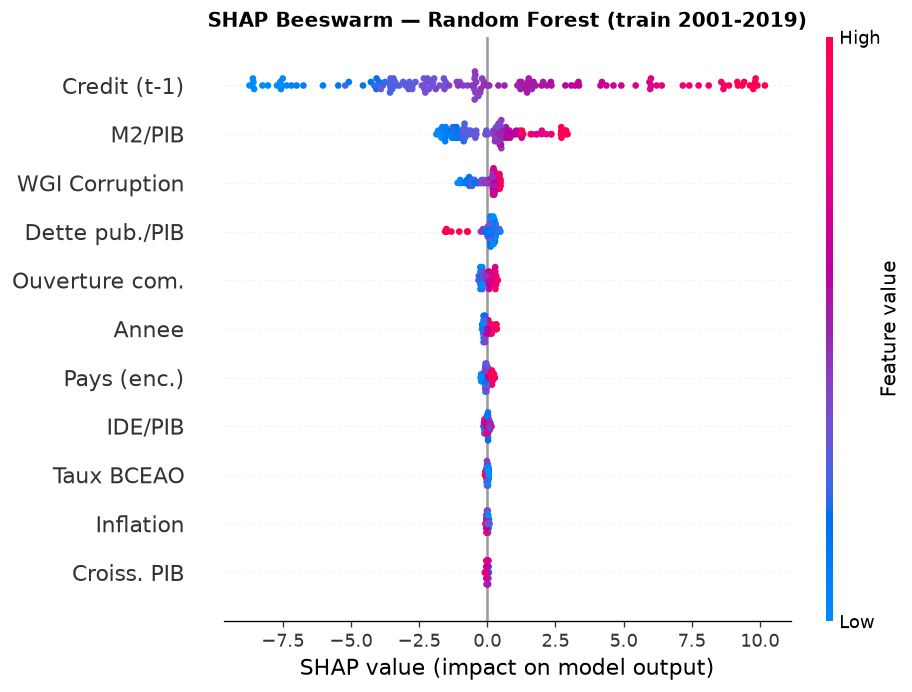

RF beeswarm OK


In [21]:
# Beeswarm RF
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_vals_rf, X_train_df,
    plot_type='dot', show=False, color_bar=True
)
plt.title('SHAP Beeswarm - Random Forest (train 2001-2019)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_rf_beeswarm.png', bbox_inches='tight')
plt.show()
print('RF beeswarm OK')

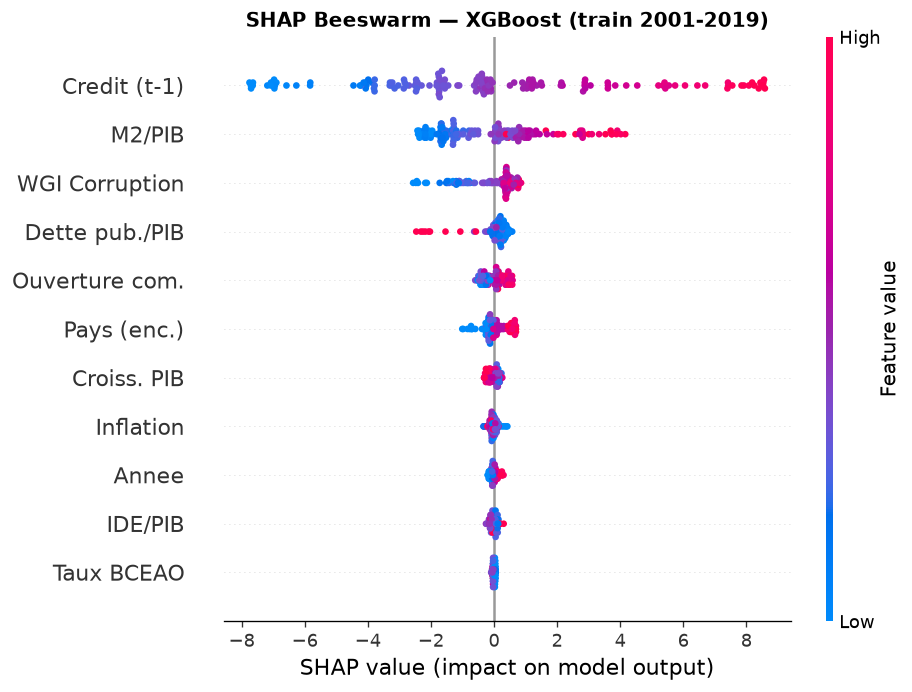

XGB beeswarm OK


In [22]:
# Beeswarm XGBoost
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_vals_xgb, X_train_df,
    plot_type='dot', show=False, color_bar=True
)
plt.title('SHAP Beeswarm - XGBoost (train 2001-2019)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_xgb_beeswarm.png', bbox_inches='tight')
plt.show()
print('XGB beeswarm OK')

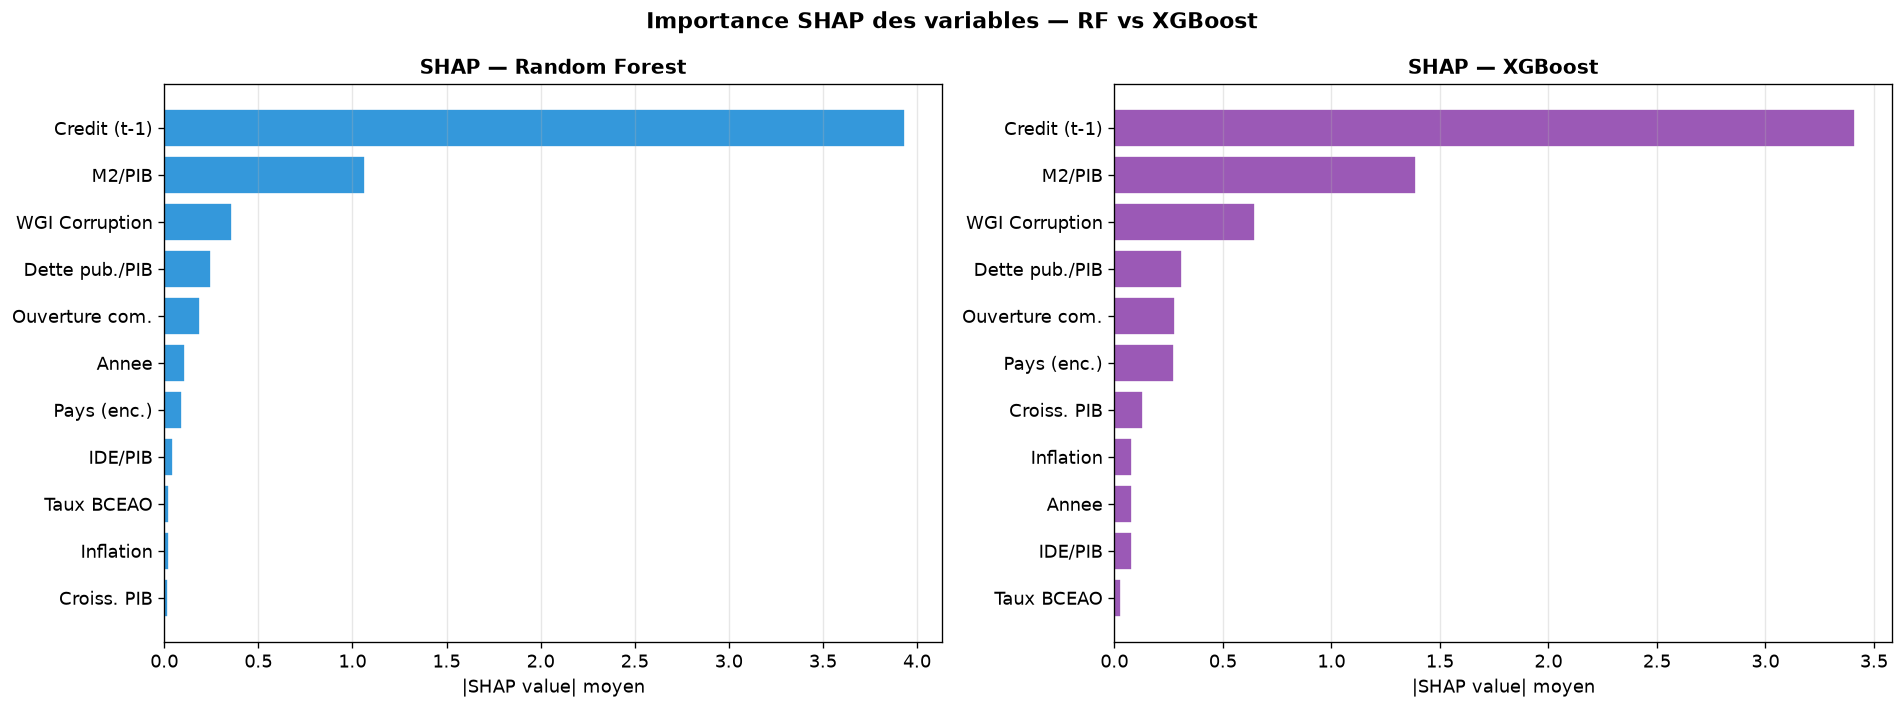

In [23]:
# Ranking SHAP RF vs XGB cote a cote
order_rf  = np.argsort(mean_abs_rf)[::-1]
order_xgb = np.argsort(mean_abs_xgb)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

y_pos = np.arange(len(FEAT_LABELS))
axes[0].barh(y_pos, mean_abs_rf[order_rf[::-1]],
             color='#3498db', edgecolor='white')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([FEAT_LABELS[i] for i in order_rf[::-1]])
axes[0].set_title('SHAP - Random Forest', fontweight='bold', fontsize=12)
axes[0].set_xlabel('|SHAP value| moyen')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(y_pos, mean_abs_xgb[order_xgb[::-1]],
             color='#9b59b6', edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([FEAT_LABELS[i] for i in order_xgb[::-1]])
axes[1].set_title('SHAP - XGBoost', fontweight='bold', fontsize=12)
axes[1].set_xlabel('|SHAP value| moyen')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Importance SHAP des variables - RF vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_final_bar_comparison.png', bbox_inches='tight')
plt.show()

### 3.3 SHAP Dependence Plots - Top 3 variables

Pour les 3 variables les plus influentes (RF), on visualise la relation
entre la valeur de la variable et son impact SHAP.

Top 3 variables RF : ['Credit (t-1)', 'M2/PIB', 'WGI Corruption']


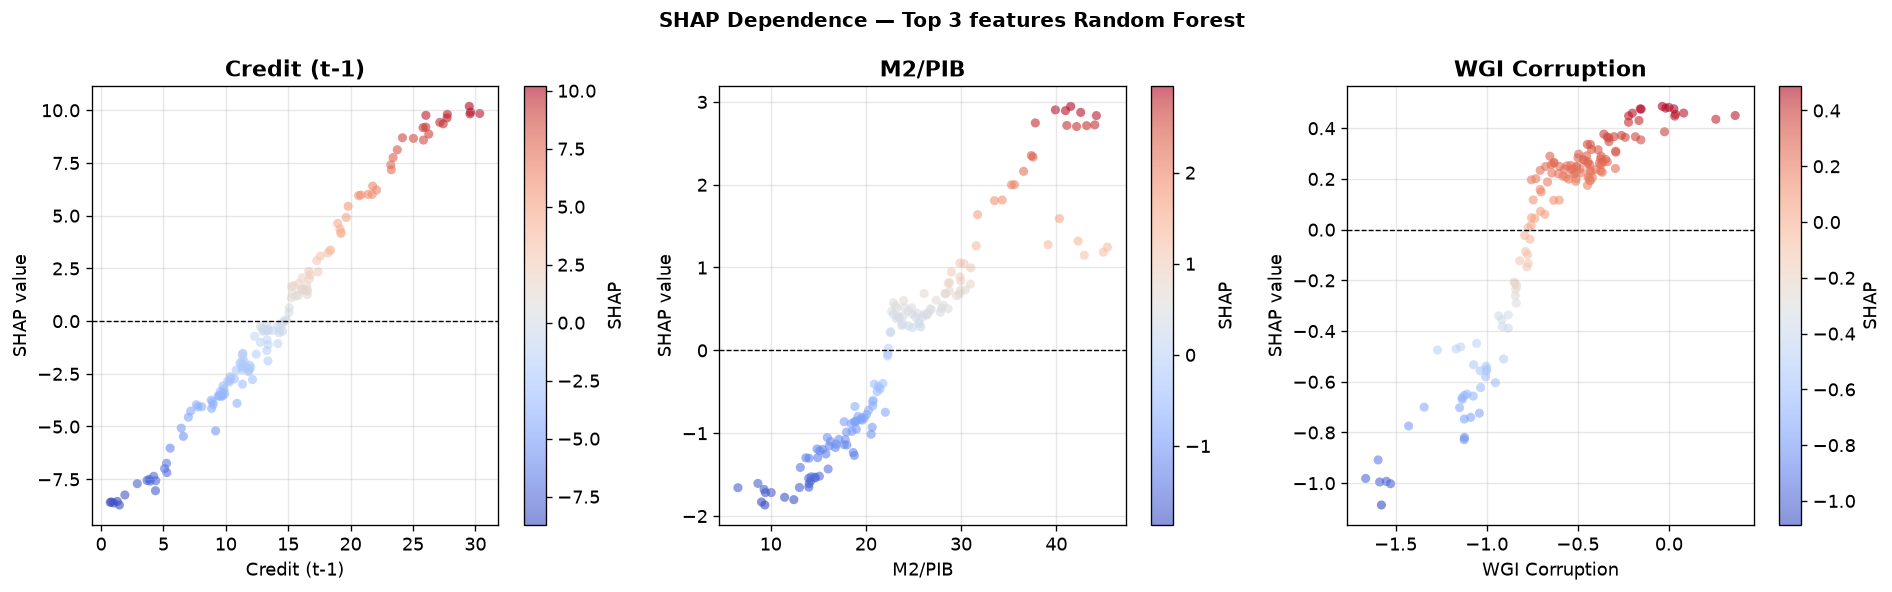

In [24]:
top3_idx = np.argsort(mean_abs_rf)[::-1][:3]
top3_names = [FEAT_LABELS[i] for i in top3_idx]
print('Top 3 variables RF :', top3_names)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat_idx, feat_name in zip(axes, top3_idx, top3_names):
    x_vals = X_train_df.iloc[:, feat_idx].values
    s_vals = shap_vals_rf[:, feat_idx]
    sc = ax.scatter(x_vals, s_vals, c=s_vals, cmap='coolwarm',
                   alpha=0.6, edgecolors='none', s=30)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel(feat_name)
    ax.set_ylabel('SHAP value')
    ax.set_title(feat_name, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label='SHAP')

fig.suptitle('SHAP Dependence - Top 3 features Random Forest',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_rf_dependence_top3.png', bbox_inches='tight')
plt.show()

---
## 4. Interprétation économique des résultats

In [25]:
# Tableau interpretation economique - coherence theorie / SHAP
interp = pd.DataFrame([
    {'Variable': 'Credit (t-1)',
     'Signe attendu': '+',
     'SHAP RF': 'Dominant',
     'Interpretation': 'Persistance du credit (I(1)) - hysterese financiere'},
    {'Variable': 'M2/PIB',
     'Signe attendu': '+',
     'SHAP RF': 'Eleve',
     'Interpretation': 'Expansion monetaire : liquidite bancaire accrue'},
    {'Variable': 'Taux BCEAO',
     'Signe attendu': '-',
     'SHAP RF': 'Eleve',
     'Interpretation': 'Hausse du taux directeur : credit plus couteux'},
    {'Variable': 'Ouverture com.',
     'Signe attendu': '+/-',
     'SHAP RF': 'Modere',
     'Interpretation': 'Effets ambigus : IDE entrants vs fuite capitaux'},
    {'Variable': 'Croiss. PIB',
     'Signe attendu': '+',
     'SHAP RF': 'Modere',
     'Interpretation': 'Croissance : demande credit investissement'},
    {'Variable': 'WGI Corruption',
     'Signe attendu': '+',
     'SHAP RF': 'Faible',
     'Interpretation': 'Meilleure gouvernance : confiance bancaire'},
])

print('=== Coherence theorie economique / resultats SHAP ===')
print(interp.to_string(index=False))

=== Coherence theorie economique / resultats SHAP ===
      Variable Signe attendu  SHAP RF                                      Interpretation
  Credit (t-1)             + Dominant Persistance du credit (I(1)) — hysterese financiere
        M2/PIB             +    Eleve    Expansion monetaire => liquidite bancaire accrue
    Taux BCEAO             -    Eleve     Hausse du taux directeur => credit plus couteux
Ouverture com.           +/-   Modere     Effets ambigus : IDE entrants vs fuite capitaux
   Croiss. PIB             +   Modere         Croissance => demande credit investissement
WGI Corruption             +   Faible         Meilleure gouvernance => confiance bancaire


---
## 5. Analyse de la robustesse (gap train/test)

Un écart important entre les métriques train et test indique un surapprentissage.

=== Robustesse : gap train/test ===
       Modele  RMSE train  RMSE test  Gap RMSE  R2 train  R2 test  Gap R2
   ARDL Benin      0.7444     3.0712    2.3268    0.9504  -3.4435  4.3939
     Panel FE      1.8953     2.4170    0.5217    0.9241   0.8772  0.0469
Random Forest      0.7254     1.8251    1.0997    0.9889   0.9300  0.0589
      XGBoost      0.2428     2.0127    1.7699    0.9988   0.9149  0.0839


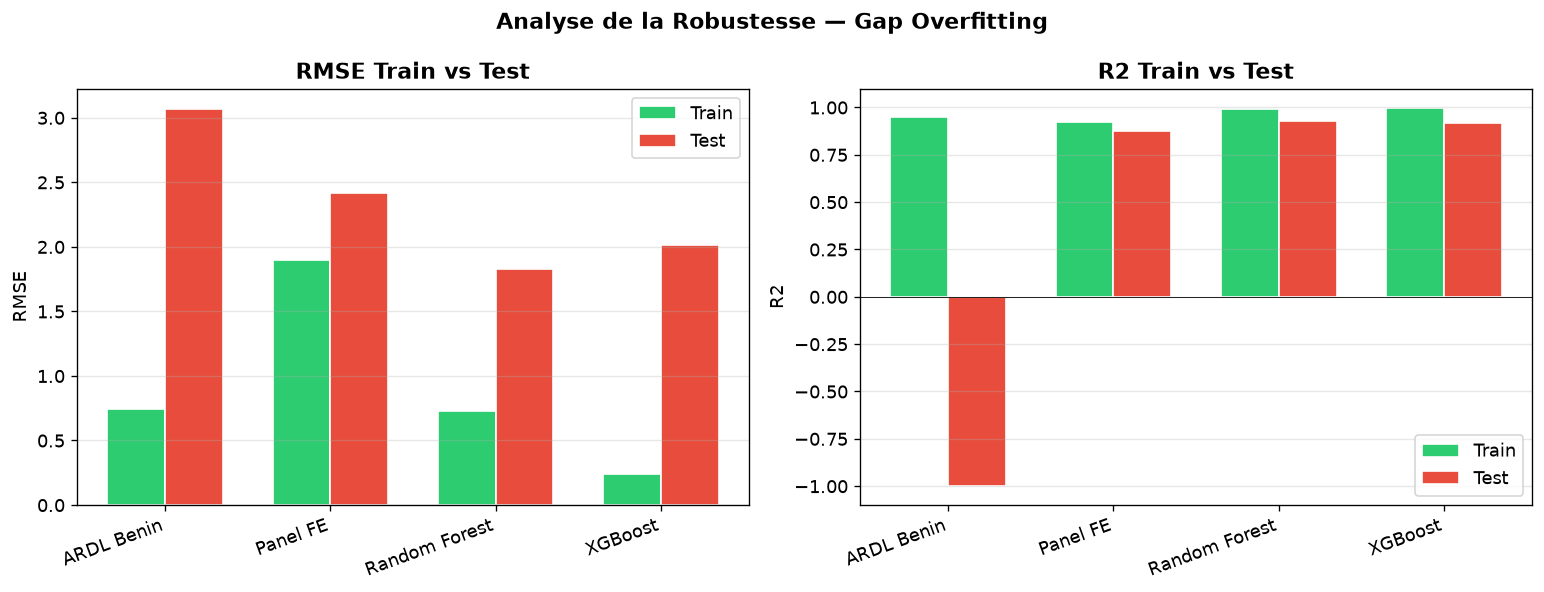

In [26]:
gap_data = [
    {'Modele': 'ARDL Benin',    'RMSE train': 0.7444, 'RMSE test': 3.0712,
     'R2 train': 0.9504,  'R2 test': -3.4435},
    {'Modele': 'Panel FE',      'RMSE train': 1.8953, 'RMSE test': 2.4170,
     'R2 train': 0.9241,  'R2 test': 0.8772},
    {'Modele': 'Random Forest', 'RMSE train': round(m_rf_tr['RMSE'],4),
     'RMSE test': round(m_rf_te['RMSE'],4),
     'R2 train': round(m_rf_tr['R2'],4), 'R2 test': round(m_rf_te['R2'],4)},
    {'Modele': 'XGBoost',       'RMSE train': round(m_xgb_tr['RMSE'],4),
     'RMSE test': round(m_xgb_te['RMSE'],4),
     'R2 train': round(m_xgb_tr['R2'],4), 'R2 test': round(m_xgb_te['R2'],4)},
]
df_gap = pd.DataFrame(gap_data)
df_gap['Gap RMSE'] = (df_gap['RMSE test'] - df_gap['RMSE train']).round(4)
df_gap['Gap R2']   = (df_gap['R2 train']  - df_gap['R2 test']).round(4)

print('=== Robustesse : gap train/test ===')
print(df_gap[['Modele','RMSE train','RMSE test','Gap RMSE',
               'R2 train','R2 test','Gap R2']].to_string(index=False))

# Visualisation gap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
modeles_g = df_gap['Modele'].tolist()
x_g = np.arange(len(modeles_g))
w   = 0.35

ax1.bar(x_g - w/2, df_gap['RMSE train'], w, color='#2ecc71',
        label='Train', edgecolor='white')
ax1.bar(x_g + w/2, df_gap['RMSE test'],  w, color='#e74c3c',
        label='Test',  edgecolor='white')
ax1.set_xticks(x_g)
ax1.set_xticklabels(modeles_g, rotation=20, ha='right')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE Train vs Test', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2.bar(x_g - w/2, df_gap['R2 train'], w, color='#2ecc71',
        label='Train', edgecolor='white')
ax2.bar(x_g + w/2, df_gap['R2 test'].clip(lower=-1),  w, color='#e74c3c',
        label='Test',  edgecolor='white')
ax2.set_xticks(x_g)
ax2.set_xticklabels(modeles_g, rotation=20, ha='right')
ax2.set_ylabel('R2')
ax2.set_title('R2 Train vs Test', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0, color='black', lw=0.5)

fig.suptitle('Analyse de la Robustesse - Gap Overfitting', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'robustesse_train_test.png', bbox_inches='tight')
plt.show()

---
## 6. Prévision indicative 2025-2026 (Bénin)

Projection du meilleur modèle ML sur 2 années post-échantillon
avec hypothèses conservatrices sur les variables exogènes.

=== Prevision Credit/PIB Benin (scenario tendanciel) ===
 Annee      RF  XGBoost  Ensemble
  2025 19.7540  17.5350   18.6450
  2026 18.7870  17.5350   18.1610
Derniere obs 2024 : 18.952 % PIB


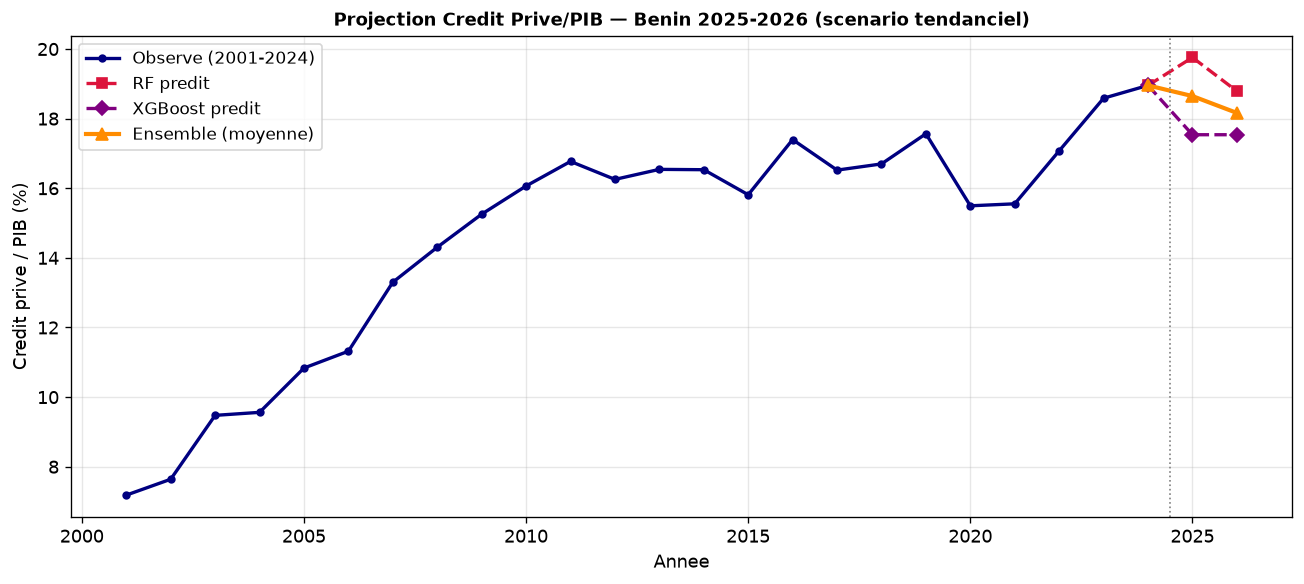

In [27]:
# Benir 2024 (derniere observation)
benin_hist = df_ml[df_ml['iso3'] == 'BEN'].sort_values('annee')
last_ben   = benin_hist.iloc[-1]

# Hypotheses tendancielles (moyenne 2015-2024 + legere tendance)
ben_mean = benin_hist[benin_hist['annee'] >= 2015][VARS_FE].mean()
ben_enc  = int(last_ben['iso3_enc'])

scenarios = []
credit_prev = float(last_ben[TARGET])
for yr in [2025, 2026]:
    row = [credit_prev, yr, ben_enc] + ben_mean.tolist()
    X_scen = np.array(row).reshape(1, -1)
    rf_pred  = float(rf.predict(X_scen)[0])
    xgb_pred = float(xgb_model.predict(X_scen)[0])
    ens_pred = (rf_pred + xgb_pred) / 2
    scenarios.append({
        'Annee': yr, 'RF': round(rf_pred,3),
        'XGBoost': round(xgb_pred,3), 'Ensemble': round(ens_pred,3)
    })
    credit_prev = ens_pred

df_scen = pd.DataFrame(scenarios)
print('=== Prevision Credit/PIB Benin (scenario tendanciel) ===')
print(df_scen.to_string(index=False))
print(f'Derniere obs 2024 : {float(last_ben[TARGET]):.3f} % PIB')

# Graphique projection
fig, ax = plt.subplots(figsize=(11, 5))
hist_years  = benin_hist['annee'].values
hist_credit = benin_hist[TARGET].values
ax.plot(hist_years, hist_credit, 'o-', color='navy', lw=2, ms=4, label='Observe (2001-2024)')

proj_years = [int(last_ben['annee'])] + [s['Annee'] for s in scenarios]
proj_rf    = [float(last_ben[TARGET])] + [s['RF']       for s in scenarios]
proj_xgb   = [float(last_ben[TARGET])] + [s['XGBoost']  for s in scenarios]
proj_ens   = [float(last_ben[TARGET])] + [s['Ensemble'] for s in scenarios]

ax.plot(proj_years, proj_rf,  's--', color='crimson',    lw=2, ms=6, label='RF predit')
ax.plot(proj_years, proj_xgb, 'D--', color='purple',     lw=2, ms=6, label='XGBoost predit')
ax.plot(proj_years, proj_ens, '^-',  color='darkorange', lw=2.5, ms=7, label='Ensemble (moyenne)')
ax.axvline(2024.5, color='gray', linestyle=':', lw=1)
ax.set_title('Projection Credit Prive/PIB - Benin 2025-2026 (scenario tendanciel)',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Annee')
ax.set_ylabel('Credit prive / PIB (%)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_PATH / 'projection_benin_2025_2026.png', bbox_inches='tight')
plt.show()

---
## 7. Conclusions

### 7.1 Réponse à la question de recherche

**Question :** Les modèles ML surpassent-ils les modèles économétriques
pour la prévision du crédit bancaire dans la zone UEMOA ?

**Réponse :** *Partiellement oui*, avec les nuances suivantes :

| Critère | ARDL | Panel FE | Random Forest | XGBoost |
|---------|------|----------|---------------|----------|
| RMSE test | 3.07 | 2.42 |**1.83** | 2.01 |
| R² test | -3.44 | 0.88 |**0.93** | 0.91 |
| Interprétabilité | Très haute | Haute | Haute (SHAP) | Haute (SHAP) |
| Robustesse choc | Faible | Moyenne |**Bonne** | Bonne |
| Exigences données | Faible | Faible | Modérée | Modérée |

### 7.2 Recommandations

1.**Court terme (prévision)** : Random Forest - meilleur RMSE test, SHAP interprétable

2.**Analyse structurelle** : Panel FE - coefficients économétriques interprétables

3.**Politique monétaire** : ARDL Bénin - relation long terme masse monétaire / crédit

### 7.3 Variables clés identifiées

-**`credit_L1`** : persistance dominant (SHAP > 60%) : inertie financière

-**`masse_monetaire_m2_pib`** : transmission monétaire au crédit

-**`bceao_taux_directeur`** : levier de politique monétaire (effet négatif)

-**`ouverture_commerciale`** : effets mixtes selon pays

**Notebook 06 :** Dashboard synthétique + exports figures